Rows after dropna: 15,588

── Summary: R² per channel ──
 Band Electrode     R2
Delta       TP9 0.1286
Delta       AF7 0.2581
Delta       AF8 0.4073
Delta      TP10 0.3906
Theta       TP9 0.1022
Theta       AF7 0.2067
Theta       AF8 0.3943
Theta      TP10 0.3460
Alpha       TP9 0.0662
Alpha       AF7 0.1941
Alpha       AF8 0.3587
Alpha      TP10 0.3751
 Beta       TP9 0.1176
 Beta       AF7 0.4330
 Beta       AF8 0.2878
 Beta      TP10 0.3858
Gamma       TP9 0.1878
Gamma       AF7 0.2577
Gamma       AF8 0.2844
Gamma      TP10 0.3668

── Mean R² per frequency band ──
Band
Delta    0.2962
Theta    0.2623
Alpha    0.2485
Beta     0.3060
Gamma    0.2742


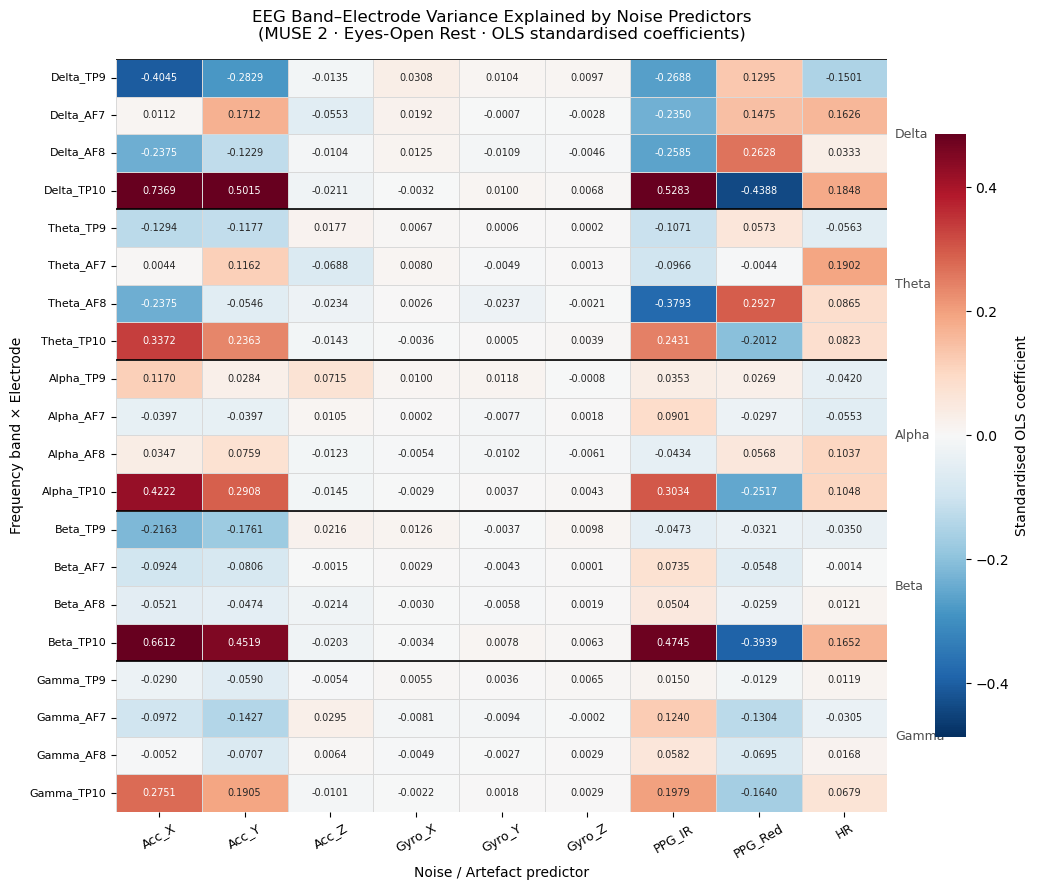


── Mean |standardised coef| per noise predictor, per band ──
  Delta : Acc_X=0.3475, PPG_IR=0.3226, Acc_Y=0.2696
  Theta : PPG_IR=0.2065, Acc_X=0.1771, PPG_Red=0.1389
  Alpha : Acc_X=0.1534, PPG_IR=0.1180, Acc_Y=0.1087
  Beta  : Acc_X=0.2555, Acc_Y=0.1890, PPG_IR=0.1614
  Gamma : Acc_Y=0.1157, Acc_X=0.1016, PPG_IR=0.0988


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# ── 1. Load ──────────────────────────────────────────────────────────────────
FILE_PATH = "mindMonitor_2026-04-18--15-57-47_1261446545740653151.csv"  # ← adjust path if needed

df = pd.read_csv(FILE_PATH, parse_dates=["TimeStamp"])

# ── 2. Define columns ────────────────────────────────────────────────────────
bands      = ["Delta", "Theta", "Alpha", "Beta", "Gamma"]
electrodes = ["TP9", "AF7", "AF8", "TP10"]

eeg_cols   = [f"{b}_{e}" for b in bands for e in electrodes]

# Noise predictors: accelerometer + gyroscope magnitude + PPG channels + Heart Rate
noise_cols = [
    "Accelerometer_X", "Accelerometer_Y", "Accelerometer_Z",
    "Gyro_X", "Gyro_Y", "Gyro_Z",
    "PPG_IR", "PPG_Red", "Heart_Rate"
]

# ── 3. Clean ─────────────────────────────────────────────────────────────────
df_clean = df[eeg_cols + noise_cols].dropna()
print(f"Rows after dropna: {len(df_clean):,}")

# ── 4. Standardise noise predictors ─────────────────────────────────────────
scaler = StandardScaler()
X = scaler.fit_transform(df_clean[noise_cols])

# ── 5. OLS per EEG channel → collect R² and coefficients ────────────────────
from numpy.linalg import lstsq

results   = {}   # {eeg_col: {"R2": float, "coefs": array}}
residuals = {}   # for variance decomposition

for col in eeg_cols:
    y = df_clean[col].values
    # add intercept column
    X_ols = np.column_stack([np.ones(len(X)), X])
    coef, _, _, _ = lstsq(X_ols, y, rcond=None)
    y_hat = X_ols @ coef
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    results[col]   = {"R2": r2, "coefs": coef[1:]}   # drop intercept
    residuals[col] = y - y_hat

# ── 6. Summary table ─────────────────────────────────────────────────────────
summary_rows = []
for col, res in results.items():
    band, elec = col.split("_", 1)
    row = {"Band": band, "Electrode": elec, "R2": round(res["R2"], 4)}
    for n, c in zip(noise_cols, res["coefs"]):
        row[n] = round(c, 6)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("\n── Summary: R² per channel ──")
print(summary_df[["Band","Electrode","R2"]].to_string(index=False))

print("\n── Mean R² per frequency band ──")
print(summary_df.groupby("Band")["R2"].mean().reindex(bands).round(4).to_string())

# ── 7. Build heatmap matrix  (rows = Band_Electrode, cols = noise params) ────
heatmap_df = summary_df.set_index(
    summary_df["Band"] + "_" + summary_df["Electrode"]
)[noise_cols]

# Short noise labels for display
short_labels = {
    "Accelerometer_X": "Acc_X", "Accelerometer_Y": "Acc_Y",
    "Accelerometer_Z": "Acc_Z", "Gyro_X": "Gyro_X",
    "Gyro_Y": "Gyro_Y",  "Gyro_Z": "Gyro_Z",
    "PPG_IR": "PPG_IR", "PPG_Red": "PPG_Red", "Heart_Rate": "HR"
}
heatmap_df.columns = [short_labels[c] for c in heatmap_df.columns]

# Row order: band-electrode grouped
row_order = [f"{b}_{e}" for b in bands for e in electrodes]
heatmap_df = heatmap_df.reindex(row_order)

# ── 8. Plot heatmap ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))

# Symmetric colour scale
vmax = np.nanpercentile(np.abs(heatmap_df.values), 98)

sns.heatmap(
    heatmap_df,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-vmax,
    vmax=vmax,
    annot=True,
    fmt=".4f",
    annot_kws={"size": 7},
    linewidths=0.4,
    linecolor="0.85",
    cbar_kws={"label": "Standardised OLS coefficient", "shrink": 0.8}
)

# Band separators
for i, band in enumerate(bands):
    ax.axhline(i * 4, color="black", linewidth=1.2)

ax.set_title(
    "EEG Band–Electrode Variance Explained by Noise Predictors\n"
    "(MUSE 2 · Eyes-Open Rest · OLS standardised coefficients)",
    fontsize=12, pad=14
)
ax.set_xlabel("Noise / Artefact predictor", fontsize=10)
ax.set_ylabel("Frequency band × Electrode", fontsize=10)
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=8)

# Band labels on the right
for i, band in enumerate(bands):
    mid = i * 4 + 2
    ax.annotate(
        band, xy=(1.01, 1 - mid / len(row_order)),
        xycoords="axes fraction",
        fontsize=9, va="center", color="0.3",
        annotation_clip=False
    )

plt.tight_layout()
plt.show()

# ── 9. Per-band noise contribution (mean |coef|) ──────────────────────────────
print("\n── Mean |standardised coef| per noise predictor, per band ──")
for band in bands:
    rows = [f"{band}_{e}" for e in electrodes]
    mean_abs = heatmap_df.loc[rows].abs().mean(axis=0)
    top = mean_abs.nlargest(3)
    print(f"  {band:6s}: {', '.join(f'{k}={v:.4f}' for k,v in top.items())}")

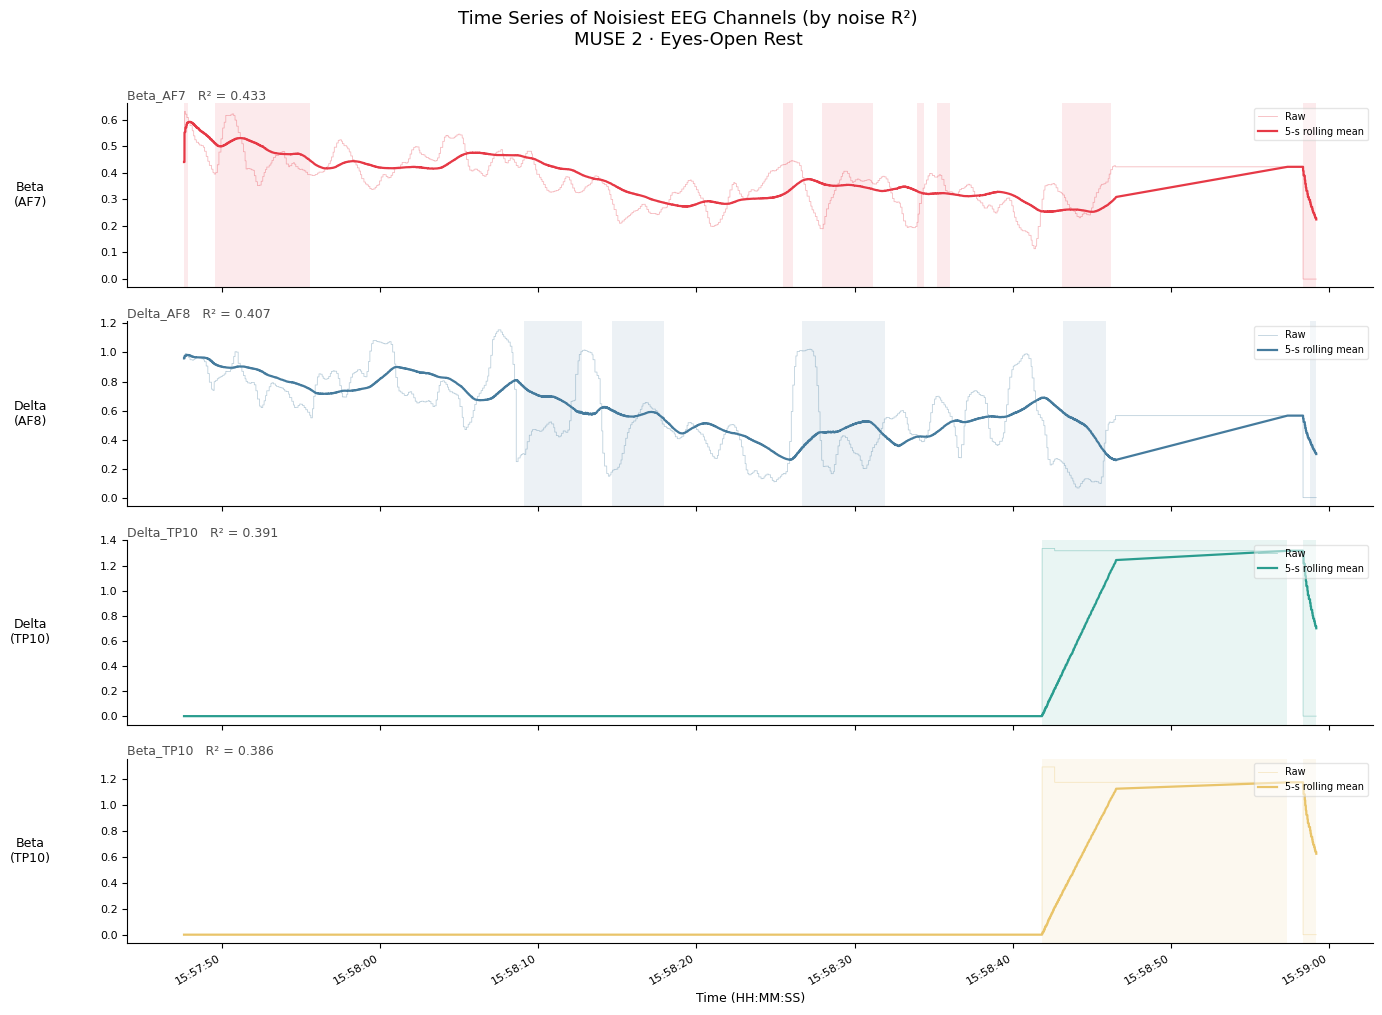

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Load (reuse df_clean + df from previous cell if still in memory) ──────────
# If kernel was restarted, uncomment and adjust path:
# FILE_PATH = "mindMonitor_2026-04-18-15-57-47_1261446545740653151.csv"
# df = pd.read_csv(FILE_PATH, parse_dates=["TimeStamp"])

# Noisiest channels by R²
noisy_channels = {
    "Beta_AF7":   0.433,
    "Delta_AF8":  0.407,
    "Delta_TP10": 0.391,
    "Beta_TP10":  0.386,
}

# Build a clean time-indexed frame for these channels
ts_cols = list(noisy_channels.keys()) + ["TimeStamp"]
ts_df = df[ts_cols].dropna().set_index("TimeStamp").sort_index()

# ── Plot ──────────────────────────────────────────────────────────────────────
colors = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a"]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
fig.suptitle(
    "Time Series of Noisiest EEG Channels (by noise R²)\nMUSE 2 · Eyes-Open Rest",
    fontsize=13, y=1.01
)

for ax, (col, r2), color in zip(axes, noisy_channels.items(), colors):
    band, elec = col.split("_", 1)

    # Thin raw line + rolling mean for readability
    ax.plot(ts_df.index, ts_df[col], color=color, alpha=0.35, linewidth=0.6, label="Raw")
    rolling = ts_df[col].rolling("5s").mean()
    ax.plot(ts_df.index, rolling, color=color, linewidth=1.6, label="5-s rolling mean")

    ax.set_ylabel(f"{band}\n({elec})", fontsize=9, rotation=0, labelpad=50, va="center")
    ax.set_title(f"{col}   R² = {r2:.3f}", fontsize=9, loc="left", pad=3, color="0.3")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top","right"]].set_visible(False)
    ax.legend(fontsize=7, loc="upper right", framealpha=0.5)

    # Shade high-noise periods: rolling std > 75th percentile
    roll_std = ts_df[col].rolling("5s").std()
    threshold = roll_std.quantile(0.75)
    high_noise = roll_std > threshold
    # Convert boolean series to contiguous spans
    in_span = False
    span_start = None
    for t, val in high_noise.items():
        if val and not in_span:
            span_start = t
            in_span = True
        elif not val and in_span:
            ax.axvspan(span_start, t, color=color, alpha=0.10, linewidth=0)
            in_span = False
    if in_span:
        ax.axvspan(span_start, ts_df.index[-1], color=color, alpha=0.10, linewidth=0)

# X-axis formatting
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=8)
axes[-1].set_xlabel("Time (HH:MM:SS)", fontsize=9)

plt.tight_layout()
plt.show()

── Pairs with |r| > 0.5 ──
  Acc_X      × Acc_Y       r = -0.844
  Acc_X      × Acc_Z       r = -0.947
  Acc_X      × PPG_IR      r = -0.691
  Acc_X      × PPG_Red     r = -0.541
  Acc_Y      × Acc_Z       r = +0.899
  Acc_Z      × PPG_IR      r = +0.559
  PPG_IR     × PPG_Red     r = +0.937
  PPG_IR     × HR          r = +0.704
  PPG_Red    × HR          r = +0.721


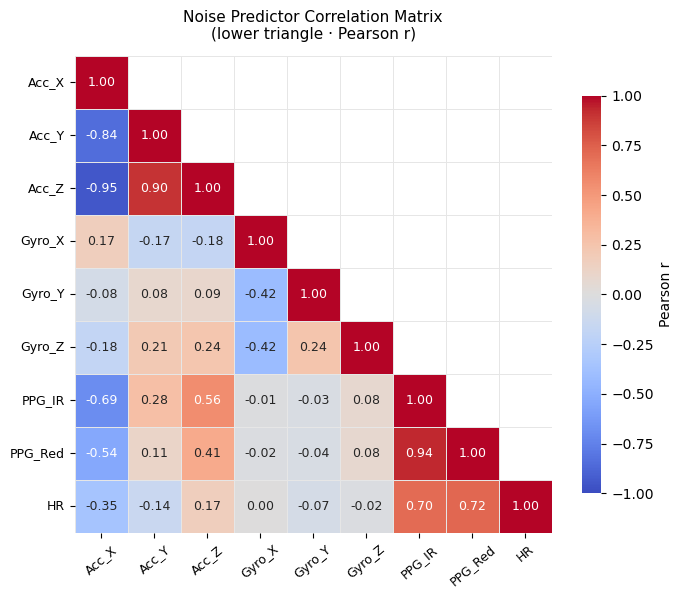

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Noise columns (same as before)
noise_cols = [
    "Accelerometer_X", "Accelerometer_Y", "Accelerometer_Z",
    "Gyro_X", "Gyro_Y", "Gyro_Z",
    "PPG_IR", "PPG_Red", "Heart_Rate"
]

short_labels = {
    "Accelerometer_X": "Acc_X", "Accelerometer_Y": "Acc_Y",
    "Accelerometer_Z": "Acc_Z", "Gyro_X": "Gyro_X",
    "Gyro_Y": "Gyro_Y",  "Gyro_Z": "Gyro_Z",
    "PPG_IR": "PPG_IR",  "PPG_Red": "PPG_Red", "Heart_Rate": "HR"
}

noise_df = df[noise_cols].dropna().rename(columns=short_labels)
corr = noise_df.corr()

# ── Print strong pairs ────────────────────────────────────────────────────────
print("── Pairs with |r| > 0.5 ──")
for i, r in enumerate(corr.columns):
    for j, c in enumerate(corr.columns):
        if j > i:
            val = corr.loc[r, c]
            if abs(val) > 0.5:
                print(f"  {r:10s} × {c:10s}  r = {val:+.3f}")

# ── Heatmap ───────────────────────────────────────────────────────────────────
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # upper triangle only

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr,
    ax=ax,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    square=True,
    linewidths=0.5,
    linecolor="0.9",
    cbar_kws={"label": "Pearson r", "shrink": 0.8}
)
ax.set_title(
    "Noise Predictor Correlation Matrix\n(lower triangle · Pearson r)",
    fontsize=11, pad=12
)
ax.tick_params(axis="x", rotation=40, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()